#Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Import machine learning library
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, r2_score, confusion_matrix

#PART 1

#Q 1 Data Understanding

In [106]:
#A. Read all the 3 CSV files as DataFrame and store them into 3 separate variables
normal = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/3.Supervised Learning/Week12_Project Submission/Normal.csv')
normal.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,38.505273,16.964297,35.112814,21.540976,127.632875,7.986683,Normal
1,54.920858,18.968430,51.601455,35.952428,125.846646,2.001642,Normal
2,44.362490,8.945435,46.902096,35.417055,129.220682,4.994195,Normal
3,48.318931,17.452121,48.000000,30.866809,128.980308,-0.910941,Normal
4,45.701789,10.659859,42.577846,35.041929,130.178314,-3.388910,Normal


In [107]:
typeh = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/3.Supervised Learning/Week12_Project Submission/Type_H.csv')
typeh.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,Type_H
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Type_H
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Type_H
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,Type_H
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Type_H


In [108]:
types = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/3.Supervised Learning/Week12_Project Submission/Type_S.csv')
types.head()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
0,74.377678,32.053104,78.772013,42.324573,143.560690,56.125906,Type_S
1,89.680567,32.704435,83.130732,56.976132,129.955476,92.027277,Type_S
2,44.529051,9.433234,52.000000,35.095817,134.711772,29.106575,Type_S
3,77.690577,21.380645,64.429442,56.309932,114.818751,26.931841,Type_S
4,76.147212,21.936186,82.961502,54.211027,123.932010,10.431972,Type_S


In [109]:
#B. Print Shape and columns of all the 3 DataFrames
print(normal.shape)
print(typeh.shape)
print(types.shape)
print(normal.columns)
print(typeh.columns)
print(types.columns)

(100, 7)
(60, 7)
(150, 7)
Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')
Index(['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree',
       'Class'],
      dtype='object')


In [110]:
#C. Compare Column names of all the 3 DataFrames and clearly write observations
if all(normal.columns == typeh.columns) and all(types.columns == typeh.columns) and all(normal.columns == types.columns):
    print("The column names of all three dataFrame are the same")
else:
    print("The column names of all three dataFrame are not same")

The column names of all three dataFrame are the same


In [111]:
#D. Print DataTypes of all the 3 DataFrames
print(normal.dtypes)
print(typeh.dtypes)
print(types.dtypes)

P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object
P_incidence    float64
P_tilt         float64
L_angle        float64
S_slope        float64
P_radius       float64
S_Degree       float64
Class           object
dtype: object


['Normal' 'Nrmal'] Class
Normal    73
Nrmal     27
Name: count, dtype: int64
['Type_H' 'type_h'] Class
Type_H    37
type_h    23
Name: count, dtype: int64
['Type_S' 'tp_s'] Class
Type_S    133
tp_s       17
Name: count, dtype: int64


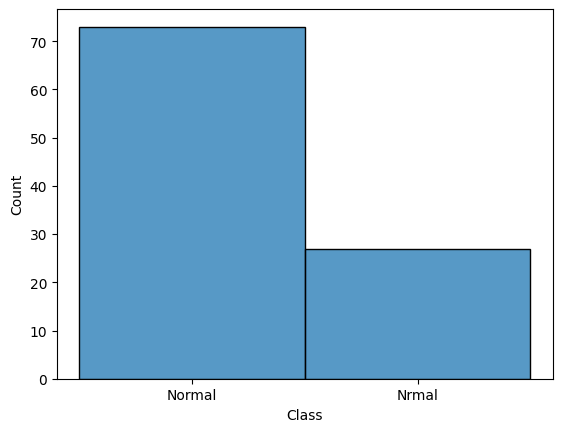

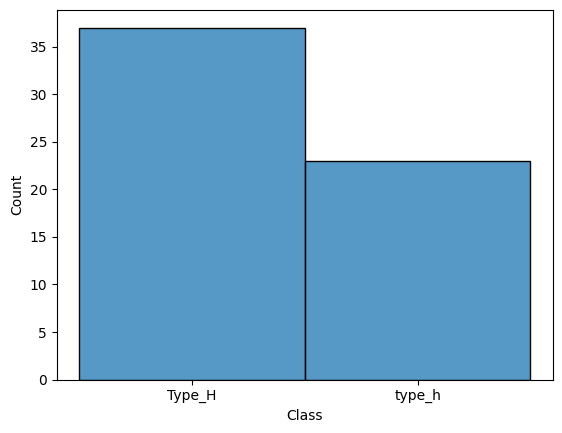

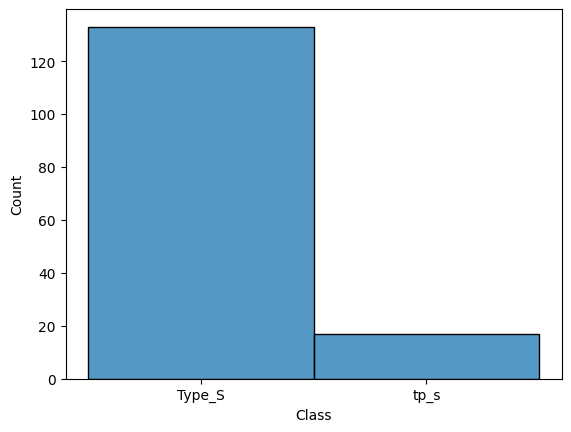

In [112]:
#E. Observe and share variation in ‘Class’ feature of all the 3 DaraFrames
print(normal['Class'].unique(), normal['Class'].value_counts())
print(typeh['Class'].unique(), typeh['Class'].value_counts())
print(types['Class'].unique(), types['Class'].value_counts())
sns.histplot(data=normal, x='Class')
plt.show()
sns.histplot(data=typeh, x='Class')
plt.show()
sns.histplot(data=types, x='Class')
plt.show()

#Q 2. Data Preparation and Exploration

In [113]:
#A. Unify all the variations in ‘Class’ feature for all the 3 DataFrames
normal['Class'].replace('Nrmal', 'Normal', inplace=True)
print(normal['Class'].unique())
typeh['Class'].replace('Type_H', 'type_h', inplace=True)
print(typeh['Class'].unique())
types['Class'].replace(['tp_s', 'Type_S'], 'type_s', inplace=True)
print(types['Class'].unique())

['Normal']
['type_h']
['type_s']


In [114]:
#B. Combine all the 3 DataFrames to form a single DataFrame
combined_df = pd.concat([normal, typeh, types])
combined_df.shape

(310, 7)

In [115]:
#C. Print 5 random samples of this DataFrame
combined_df.sample(n=5)

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree,Class
68,40.413366,-1.329412,30.982768,41.742778,119.335655,-6.173675,Normal
33,38.663257,12.986441,40.000000,25.676816,124.914118,2.703008,type_h
89,82.905351,29.894119,58.250542,53.011232,110.708958,6.079338,Normal
60,51.311771,8.875541,57.000000,42.436230,126.472258,-2.144044,Normal
12,56.103774,13.106307,62.637020,42.997467,116.228503,31.172767,Normal


In [116]:
#D. Print Feature-wise percentage of Null values
(combined_df.isnull().mean() * 100).round(2)

P_incidence    0.0
P_tilt         0.0
L_angle        0.0
S_slope        0.0
P_radius       0.0
S_Degree       0.0
Class          0.0
dtype: float64

In [117]:
#E. Check 5-point summary of the new DataFrame
combined_df.describe()

,P_incidence,P_tilt,L_angle,S_slope,P_radius,S_Degree
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


#Q 3. Data Analysis

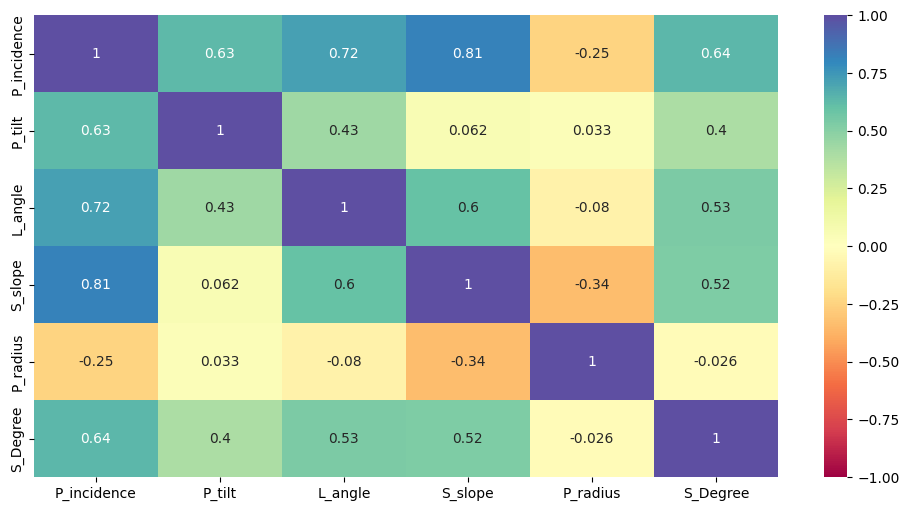

In [118]:
#A. Visualize a heatmap to understand correlation between all features
plt.figure(figsize=(12,6))
sns.heatmap(combined_df[['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree']].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

In [119]:
#B. Share insights on correlation
#A. Features having stronger correlation with correlation value.
print('Features having stronger correlation {} and {} having positive correlation value {}'.format('P_incidence', 'S_slope', 0.81))
#B. Features having weaker correlation with correlation value.
print('Features having weaker correlation {} and {} having negative correlation value {}'.format('P_radius', 'S_slope', -0.34))

Features having stronger correlation P_incidence and S_slope having positive correlation value 0.81
Features having weaker correlation P_radius and S_slope having negative correlation value -0.34


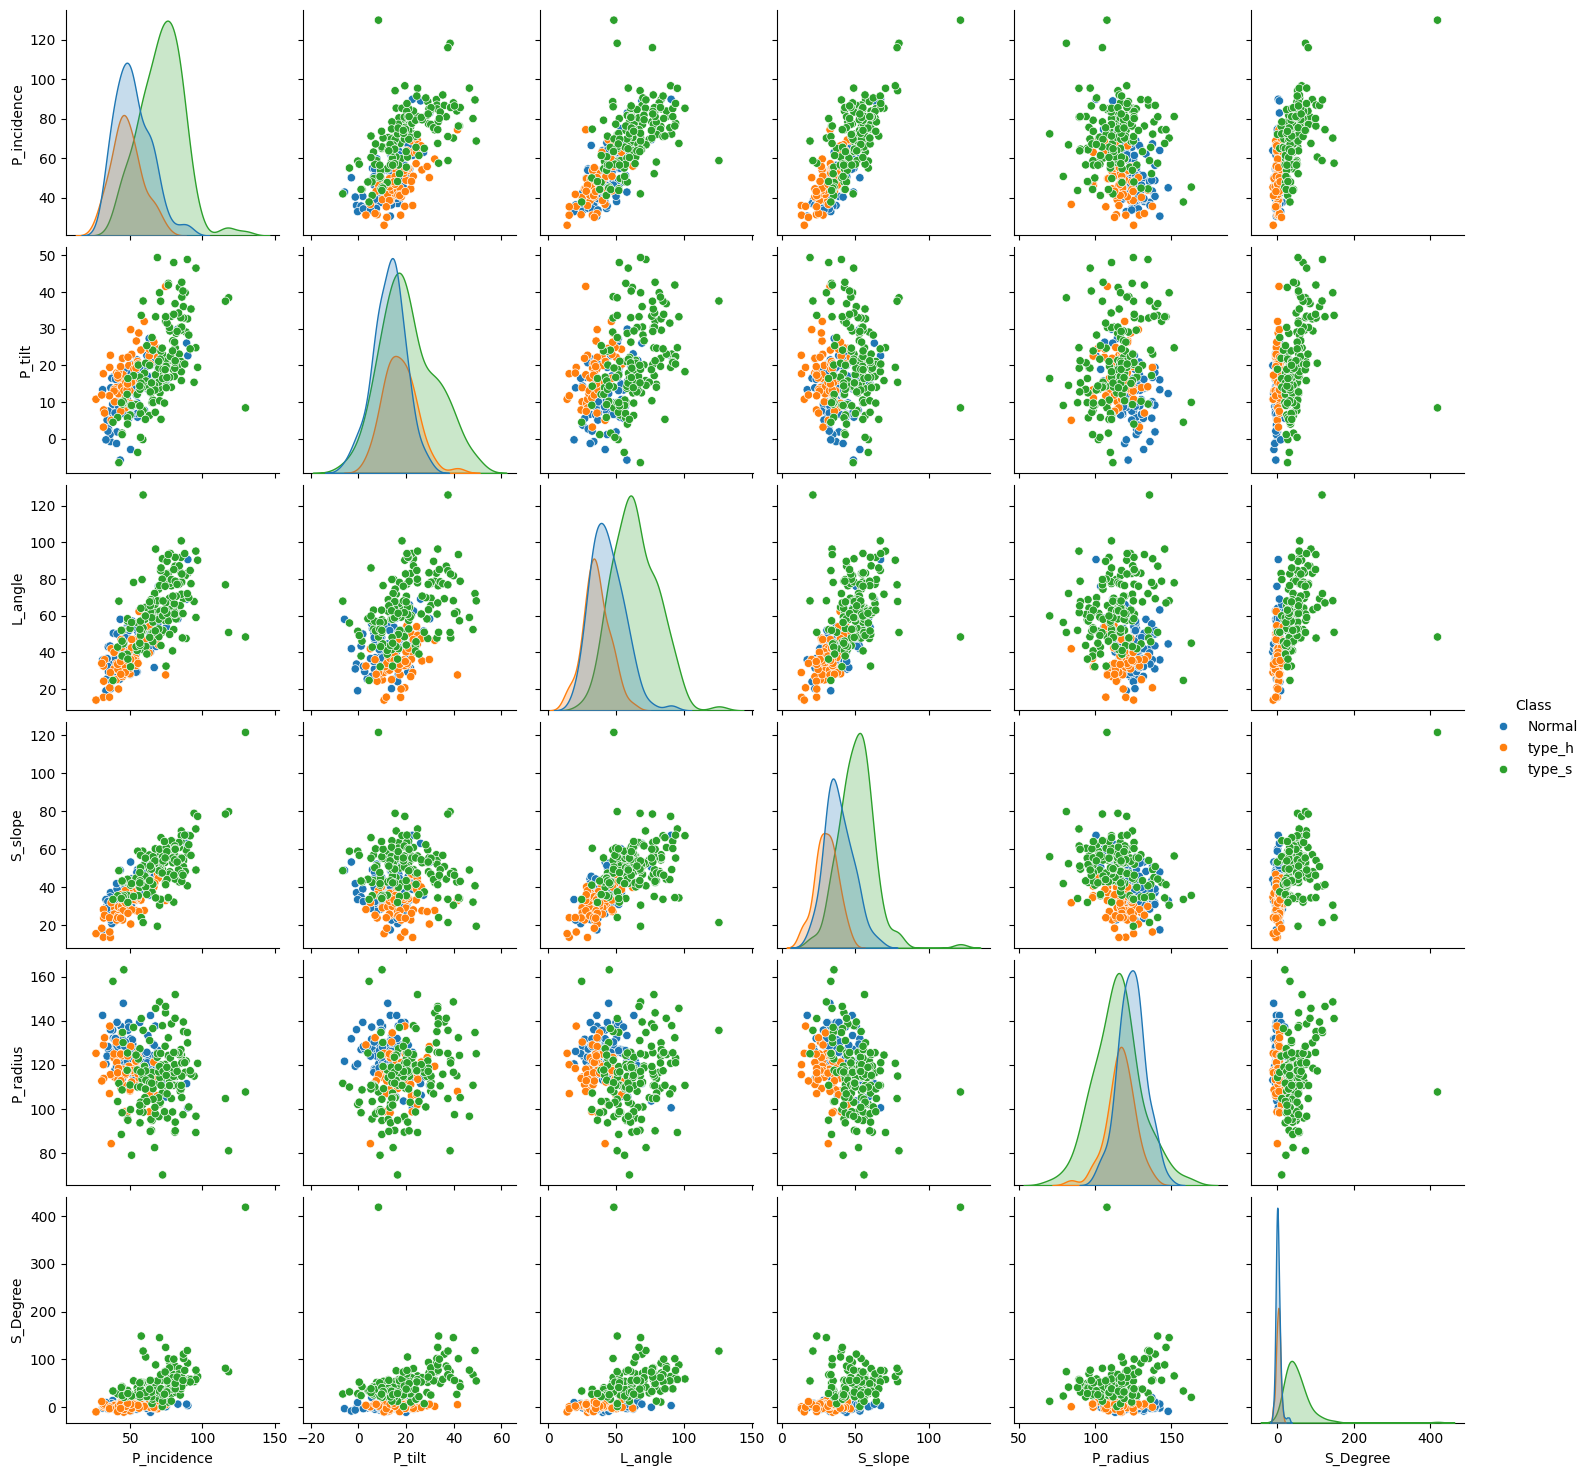

In [120]:
#C. Visualize a pairplot with 3 classes distinguished by colors and share insights.
sns.pairplot(combined_df, hue='Class')
plt.show()

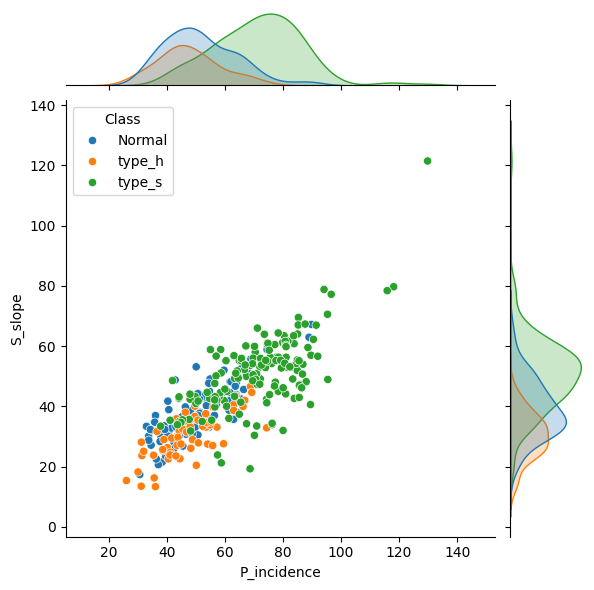

Looking on to the Joint plot it can be conclude that ‘P_incidence’ and ‘S_slope’ have positive corelation 


In [121]:
#D. Visualize a jointplot for ‘P_incidence’ and ‘S_slope’ and share insights.
sns.jointplot(data=combined_df, x='P_incidence', y='S_slope', kind='scatter', hue='Class')
plt.show()
print('Looking on to the Joint plot it can be conclude that ‘P_incidence’ and ‘S_slope’ have positive corelation ')

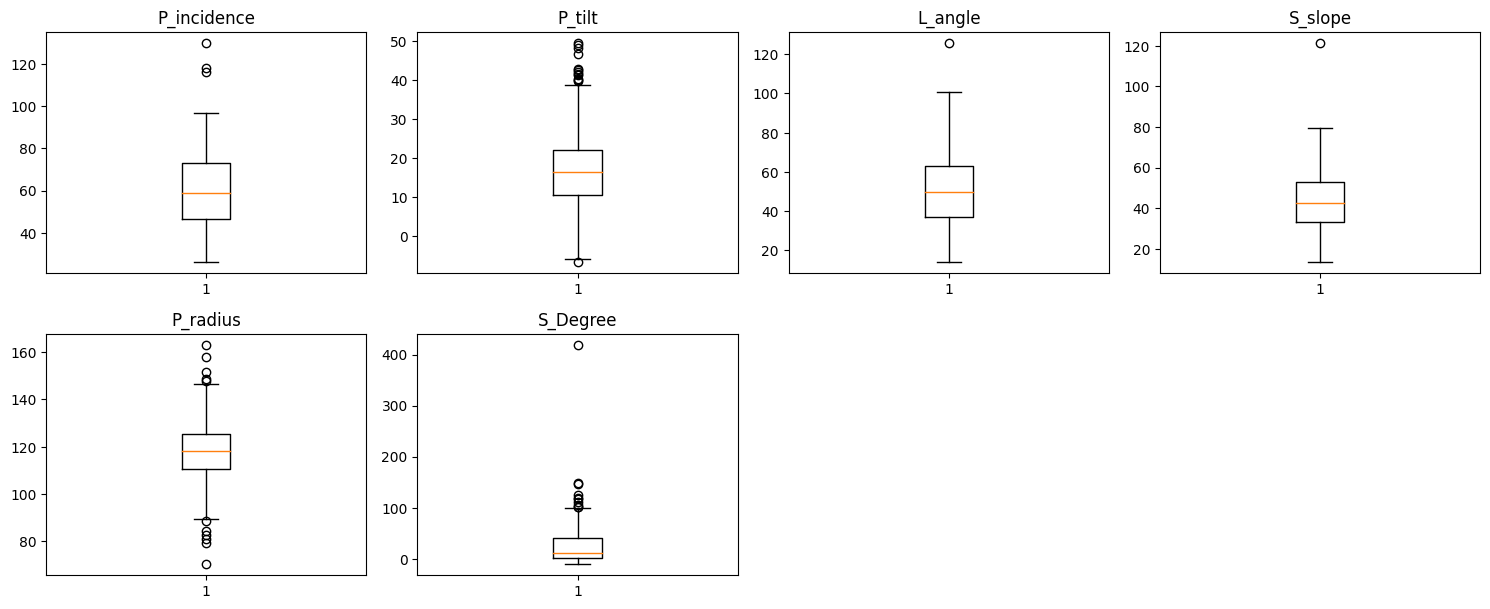

In [122]:
#E. Visualize a boxplot to check distribution of the features and share insights.
# outlier detection using boxplot
# selecting the numerical columns of combined_df and adding their names in a list
numeric_columns = ['P_incidence', 'P_tilt', 'L_angle', 'S_slope', 'P_radius', 'S_Degree']
plt.figure(figsize=(15, 12))
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(combined_df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)
plt.show()

Insights

P_incidence, P_tilt and S_Degree are right skewed and lot of right outliers

P_radius has outliers on both side

L_angle and S_slope has very fiew right outliers

#Q 4. Model Building

In [123]:
#A. Split data into X and Y.
# independant variables
X = combined_df.drop(['Class'], axis=1).values
# the dependent variable
y = combined_df['Class'].values
print(X[0:5])
print(y[0:5])

[[ 38.50527283  16.96429691  35.11281407  21.54097592 127.6328747
    7.98668323]
 [ 54.92085752  18.96842952  51.60145541  35.952428   125.8466462
    2.00164247]
 [ 44.36249017   8.94543489  46.90209626  35.41705528 129.220682
    4.99419529]
 [ 48.3189305   17.45212105  47.99999999  30.86680945 128.9803079
   -0.91094057]
 [ 45.70178875  10.65985935  42.5778464   35.0419294  130.1783144
   -3.38890999]]
['Normal' 'Normal' 'Normal' 'Normal' 'Normal']


In [124]:
#B. Split data into train and test with 80:20 proportion.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [125]:
#C. Train a Supervised Learning Classification base model using KNN classifier.
X_train_norm = StandardScaler().fit_transform(X_train)
X_test_norm = StandardScaler().fit_transform(X_test)
k = 3
#Train Model and Predict
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train_norm,y_train)
yhat = neigh.predict(X_test_norm)

In [126]:
#D. Print all the possible performance metrics for both train and test data
print('Train data performance metrics:')
print(classification_report(y_train, neigh.predict(X_train_norm)))
print('Test data performance metrics:')
print(classification_report(y_test, yhat))
report = classification_report(y_test, yhat, output_dict=True)

Train data performance metrics:
              precision    recall  f1-score   support

      Normal       0.80      0.87      0.83        82
      type_h       0.83      0.78      0.80        49
      type_s       0.96      0.93      0.95       117

    accuracy                           0.88       248
   macro avg       0.86      0.86      0.86       248
weighted avg       0.88      0.88      0.88       248

Test data performance metrics:
              precision    recall  f1-score   support

      Normal       0.52      0.61      0.56        18
      type_h       0.58      0.64      0.61        11
      type_s       0.86      0.76      0.81        33

    accuracy                           0.69        62
   macro avg       0.66      0.67      0.66        62
weighted avg       0.71      0.69      0.70        62



#Q 5. Performance Improvement

In [127]:
#A. Experiment with various parameters to improve performance of the base model.
#List Hyperparameters that we want to tune.
leaf_size = list(range(1,50))
n_neighbors = list(range(1,30))
p=[1,2]
#Convert to dictionary
hyperparameters = dict(leaf_size=leaf_size, n_neighbors=n_neighbors, p=p)
#Create new KNN object
knn_2 = KNeighborsClassifier()
#Use GridSearch
clf = GridSearchCV(knn_2, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X,y)
#Print The value of best Hyperparameters
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])

Best leaf_size: 1
Best p: 2
Best n_neighbors: 25


In [128]:
tuned_k_value = best_model.best_estimator_.get_params()['n_neighbors']
neigh_i = KNeighborsClassifier(n_neighbors = tuned_k_value).fit(X_train_norm,y_train)
yhat_i = neigh_i.predict(X_test_norm)
#Checking performance our model with classification report.
print(classification_report(y_test, yhat_i))

              precision    recall  f1-score   support

      Normal       0.57      0.67      0.62        18
      type_h       0.67      0.73      0.70        11
      type_s       0.86      0.76      0.81        33

    accuracy                           0.73        62
   macro avg       0.70      0.72      0.71        62
weighted avg       0.74      0.73      0.73        62



In [129]:
#B. Clearly showcase improvement in performance achieved.
report_tuned = classification_report(y_test, yhat_i, output_dict=True)
# prev report
print("After hyperparameters tuning accuracy: ", round(float(report_tuned['accuracy'])-float(report['accuracy']), 2)*100,'% improvement')
print("After hyperparameters tuning precision: ", round(float(report_tuned[str('macro avg')]['precision'])-float(report[str('macro avg')]['precision']), 2)*100,'% improvement')


After hyperparameters tuning accuracy:  3.0 % improvement
After hyperparameters tuning precision:  4.0 % improvement


In [130]:
#C. Clearly state which parameters contributed most to improve model performance
print('Parameter which contributed to improve performance is K = {}'.format(tuned_k_value))

Parameter which contributed to improve performance is K = 25


#Part 2

#Q 1. Data Understanding and Preparation

In [85]:
#A. Read both the Datasets ‘Data1’ and ‘Data 2’ as DataFrame and store them into two separate variables
data1 = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/3.Supervised Learning/Week12_Project Submission/Data1.csv')
data1.head()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level
0,1,25,1,49,91107,4,1.6,1
1,2,45,19,34,90089,3,1.5,1
2,3,39,15,11,94720,1,1.0,1
3,4,35,9,100,94112,1,2.7,2
4,5,35,8,45,91330,4,1.0,2


In [86]:
data2 = pd.read_csv('/content/drive/MyDrive/DS_AIML/AIML_PGP_Code/3.Supervised Learning/Week12_Project Submission/Data2.csv')
data2.head()

,ID,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
0,1,0,1,0,0,0,NaN
1,2,0,1,0,0,0,NaN
2,3,0,0,0,0,0,NaN
3,4,0,0,0,0,0,NaN
4,5,0,0,0,0,1,NaN


In [87]:
#B. Print shape and Column Names and DataTypes of both the Dataframes.
print(data1.shape)
print(data2.shape)
print(data1.columns)
print(data2.columns)
print(data1.dtypes)
print(data2.dtypes)

(5000, 8)
(5000, 7)
Index(['ID', 'Age', 'CustomerSince', 'HighestSpend', 'ZipCode', 'HiddenScore',
       'MonthlyAverageSpend', 'Level'],
      dtype='object')
Index(['ID', 'Mortgage', 'Security', 'FixedDepositAccount', 'InternetBanking',
       'CreditCard', 'LoanOnCard'],
      dtype='object')
ID                       int64
Age                      int64
CustomerSince            int64
HighestSpend             int64
ZipCode                  int64
HiddenScore              int64
MonthlyAverageSpend    float64
Level                    int64
dtype: object
ID                       int64
Mortgage                 int64
Security                 int64
FixedDepositAccount      int64
InternetBanking          int64
CreditCard               int64
LoanOnCard             float64
dtype: object


In [88]:
#C. Merge both the Dataframes on ‘ID’ feature to form a single DataFrame
merged_df = data1.merge(data2, on='ID')
merged_df.tail()

,ID,Age,CustomerSince,HighestSpend,ZipCode,HiddenScore,MonthlyAverageSpend,Level,Mortgage,Security,FixedDepositAccount,InternetBanking,CreditCard,LoanOnCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,1,0,0.0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,1,0,0.0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0.0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,1,0,0.0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,1,1,0.0


In [89]:
#D. Change Datatype of ‘CreditCard’, ‘InternetBanking’, ‘FixedDepositAccount’, ‘Security’, ‘Level’, ‘HiddenScore’. features to ‘Object’
merged_df['HiddenScore'] = merged_df['HiddenScore'].astype(object)
merged_df['Level'] = merged_df['Level'].astype(object)
merged_df['Security'] = merged_df['Security'].astype(object)
merged_df['FixedDepositAccount'] = merged_df['FixedDepositAccount'].astype(object)
merged_df['InternetBanking'] = merged_df['InternetBanking'].astype(object)
merged_df['CreditCard'] = merged_df['CreditCard'].astype(object)

#Q 2. Data Exploration and Analysis

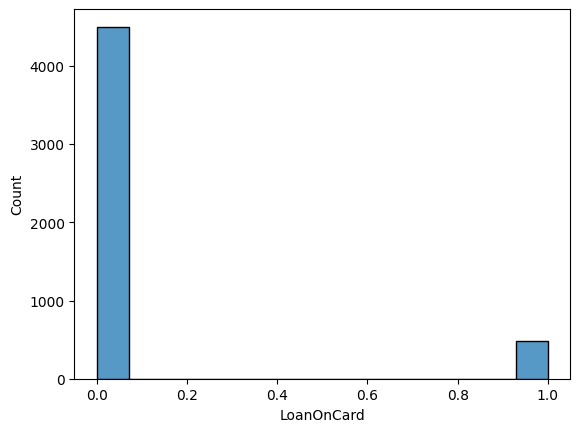

Looking on to the plot it is clear that distribution of the target variable is not balance 0 values are more as compare to 1


In [90]:
#A. Visualize distribution of Target variable ‘LoanOnCard’ and clearly share insights.
merged_df.isnull().sum()
sns.histplot(data=merged_df, x='LoanOnCard')
plt.show()
print('Looking on to the plot it is clear that distribution of the target variable is not balance 0 values are more as compare to 1')

In [91]:
#B. Check the percentage of missing values and impute if required.
print((merged_df.isnull().mean() * 100).round(2))
merged_df.dropna(inplace=True)
print(merged_df.shape)

ID                     0.0
Age                    0.0
CustomerSince          0.0
HighestSpend           0.0
ZipCode                0.0
HiddenScore            0.0
MonthlyAverageSpend    0.0
Level                  0.0
Mortgage               0.0
Security               0.0
FixedDepositAccount    0.0
InternetBanking        0.0
CreditCard             0.0
LoanOnCard             0.4
dtype: float64
(4980, 14)


In [92]:
#C. Check for unexpected values in each categorical variable and impute with best suitable value
print(merged_df['HiddenScore'].unique())
print(merged_df['Level'].unique())
print(merged_df['Security'].unique())
print(merged_df['FixedDepositAccount'].unique())
print(merged_df['InternetBanking'].unique())
print(merged_df['CreditCard'].unique())

[1 4 3 2]
[3 2 1]
[0 1]
[0 1]
[0 1]
[0 1]


#Q 3. Data Preparation and model building

In [93]:
#A. Split data into X and Y.
# independant variables
X = merged_df.drop(['LoanOnCard', 'ID', 'ZipCode'], axis=1).values
# the dependent variable
y = merged_df['LoanOnCard'].values

In [94]:
#B. Split data into train and test. Keep 25% data reserved for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [95]:
#C. Train a Supervised Learning Classification base model - Logistic Regression.
X_train_norm = StandardScaler().fit_transform(X_train)
X_test_norm = StandardScaler().fit_transform(X_test)
#Train Model and Predict
lr = LogisticRegression().fit(X_train_norm,y_train)
yhat = lr.predict(X_test_norm)

In [96]:
#D. Print evaluation metrics for the model and clearly share insights.
#Checking performance our model with classification report.
print(classification_report(y_test, yhat))
#Checking performance our model with ROC Score.
roc_auc = roc_auc_score(y_test, yhat)
print('ROC_AUC score : ', roc_auc)
reportl = classification_report(y_test, yhat, output_dict=True)

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      1118
         1.0       0.87      0.62      0.72       127

    accuracy                           0.95      1245
   macro avg       0.91      0.81      0.85      1245
weighted avg       0.95      0.95      0.95      1245

ROC_AUC score :  0.8056568957502853


In [97]:
#E. Balance the data using the right balancing technique.

#i. Check distribution of the target variable
print(merged_df['LoanOnCard'].value_counts())

#ii. Say output is class A : 20% and class B : 80%

#iii. Here you need to balance the target variable as 50:50

#iv. Try appropriate method to achieve the same
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
# Oversampling with ADASYN
oversample = ADASYN(sampling_strategy='auto')
X_resampled, y_resampled = oversample.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=1)

LoanOnCard
0.0    4500
1.0     480
Name: count, dtype: int64


In [98]:
#F. Again train the same previous model on balanced data.
X_train_norm = StandardScaler().fit_transform(X_train)
X_test_norm = StandardScaler().fit_transform(X_test)
lrb = LogisticRegression().fit(X_train_norm,y_train)
yhat = lrb.predict(X_test_norm)

In [99]:
#G. Print evaluation metrics and clearly share differences observed
print(classification_report(y_test, yhat))
print('ROC_AUC score :', roc_auc_score(y_test, yhat))
tuned_reportl = classification_report(y_test, yhat, output_dict=True)
print("After balancing data accuracy: ", round(float(tuned_reportl['accuracy'])-float(reportl['accuracy']), 2)*100,'% improvement')
print("After balancing data precision: ", round(float(tuned_reportl[str('macro avg')]['precision'])-float(reportl[str('macro avg')]['precision']), 2)*100,'% improvement')
print('After balancing data ROC_AUC score: ',round(roc_auc_score(y_test, yhat)-roc_auc,2)*100,'% improvement')

              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90      1112
         1.0       0.91      0.91      0.91      1143

    accuracy                           0.91      2255
   macro avg       0.91      0.91      0.91      2255
weighted avg       0.91      0.91      0.91      2255

ROC_AUC score : 0.9059933155837534
After balancing data accuracy:  -5.0 % improvement
After balancing data precision:  -1.0 % improvement
After balancing data ROC_AUC score:  10.0 % improvement


#Q 4. Performance Improvement

In [100]:
#A. Train a base model each for SVM, KNN
#SVM
svm = SVC().fit(X_train_norm,y_train)
svm_yhat = svm.predict(X_test_norm)
#KNN
knn = KNeighborsClassifier().fit(X_train_norm,y_train)
knn_yhat = knn.predict(X_test_norm)

print('SVM score: ')
report_svm = classification_report(y_test, svm_yhat, output_dict=True)
print(classification_report(y_test, svm_yhat))
roc_auc_svm = roc_auc_score(y_test, svm_yhat)
print('ROC_AUC score: ',roc_auc_svm)
print('KNN score : ')
report_knn = classification_report(y_test, svm_yhat, output_dict=True)
print(classification_report(y_test, svm_yhat))
roc_auc_knn = roc_auc_score(y_test, knn_yhat)
print('ROC_AUC score: ',roc_auc_knn)

SVM score: 
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1112
         1.0       0.98      0.99      0.98      1143

    accuracy                           0.98      2255
   macro avg       0.98      0.98      0.98      2255
weighted avg       0.98      0.98      0.98      2255

ROC_AUC score:  0.9830722036543993
KNN score : 
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1112
         1.0       0.98      0.99      0.98      1143

    accuracy                           0.98      2255
   macro avg       0.98      0.98      0.98      2255
weighted avg       0.98      0.98      0.98      2255

ROC_AUC score:  0.9784660460607891


In [101]:
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1]}
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=5)
grid_search.fit(X, y)
print("Best hyperparameters for SVM:", grid_search.best_params_)

Best hyperparameters for SVM: {'C': 100, 'gamma': 0.001}


In [102]:
#B. Tune parameters for each of the models wherever required and finalize a model
#List Hyperparameters that we want to tune.
leaf_size = list(range(1,50))
n_neighbors = list(range(1,30))
p=[1,2]
#Convert to dictionary
hyperparameters = dict(leaf_size=leaf_size, n_neighbors=n_neighbors, p=p)
#Create new KNN object
knn_2 = KNeighborsClassifier()
#Use GridSearch
clf = GridSearchCV(knn_2, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X,y)
#Print The value of best Hyperparameters
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])

Best leaf_size: 3
Best p: 1
Best n_neighbors: 9


In [103]:
tuned_c = grid_search.best_params_['C']
tuned_gamma = grid_search.best_params_['gamma']
tuned_k = best_model.best_estimator_.get_params()['n_neighbors']
print('tuned_c: ', tuned_c, 'tuned_gamma: ', tuned_gamma, 'tuned_k: ', tuned_k)

tuned_c:  100 tuned_gamma:  0.001 tuned_k:  9


In [104]:
#C. Print evaluation metrics for final model
#SVM after hyperparameter tuning
svmf = SVC(C= tuned_c, gamma= tuned_gamma).fit(X_train_norm,y_train)
svmf_yhat = svmf.predict(X_test_norm)
#KNN after hyperparameter tuning
knnf = KNeighborsClassifier(n_neighbors = tuned_k).fit(X_train_norm,y_train)
knnf_yhat = knn.predict(X_test_norm)

print('SVM score after hyperparameter tuning:')
print(classification_report(y_test, svmf_yhat))
print(roc_auc_score(y_test, svmf_yhat))
print('KNN score after hyperparameter tuning :')
print(classification_report(y_test, knnf_yhat))
print(roc_auc_score(y_test, knnf_yhat))

SVM score after hyperparameter tuning:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96      1112
         1.0       0.96      0.96      0.96      1143

    accuracy                           0.96      2255
   macro avg       0.96      0.96      0.96      2255
weighted avg       0.96      0.96      0.96      2255

0.9609316483820818
KNN score after hyperparameter tuning :
              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98      1112
         1.0       0.96      1.00      0.98      1143

    accuracy                           0.98      2255
   macro avg       0.98      0.98      0.98      2255
weighted avg       0.98      0.98      0.98      2255

0.9784660460607891


In [105]:
#D. Share improvement achieved from base model to final model
tuned_report_svm = classification_report(y_test, svmf_yhat, output_dict=True)
print("After hyperparameters tuning SVM accuracy: ", round(float(tuned_report_svm['accuracy'])-float(report_svm['accuracy']), 2)*100,'% improvement')
print("After hyperparameters tuning SVM precision: ", round(float(tuned_report_svm[str('macro avg')]['precision'])-float(report_svm[str('macro avg')]['precision']), 2)*100,'% improvement')
print('After hyperparameters tuning ROC_AUC score for SVM : ',round(roc_auc_score(y_test, svmf_yhat)-roc_auc_svm,2)*100,'% improvement')

tuned_report_knn = classification_report(y_test, knnf_yhat, output_dict=True)
print("After hyperparameters tuning KNN accuracy: ", round(float(tuned_report_knn['accuracy'])-float(report_knn['accuracy']), 2)*100,'% improvement')
print("After hyperparameters tuning KNN precision: ", round(float(tuned_report_knn[str('macro avg')]['precision'])-float(report_knn[str('macro avg')]['precision']), 2)*100,'% improvement')
print('After hyperparameters tuning ROC_AUC score for KNN : ',round(roc_auc_score(y_test, knnf_yhat)-roc_auc_knn,2)*100,'% improvement')


After hyperparameters tuning SVM accuracy:  -2.0 % improvement
After hyperparameters tuning SVM precision:  -2.0 % improvement
After hyperparameters tuning ROC_AUC score for SVM :  -2.0 % improvement
After hyperparameters tuning KNN accuracy:  -0.0 % improvement
After hyperparameters tuning KNN precision:  -0.0 % improvement
After hyperparameters tuning ROC_AUC score for KNN :  0.0 % improvement
